In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from torch.quantization import quantize_dynamic

In [3]:
X, y = make_moons(n_samples=5000, noise=0.5, random_state=42)

In [4]:
X

array([[ 0.64527536,  1.38251014],
       [ 0.14514823, -0.32157033],
       [ 0.11945131,  0.41631146],
       ...,
       [ 0.6360473 ,  0.66530771],
       [ 1.61542641, -0.24249711],
       [ 0.10599548,  1.0899585 ]], shape=(5000, 2))

In [5]:
X.shape

(5000, 2)

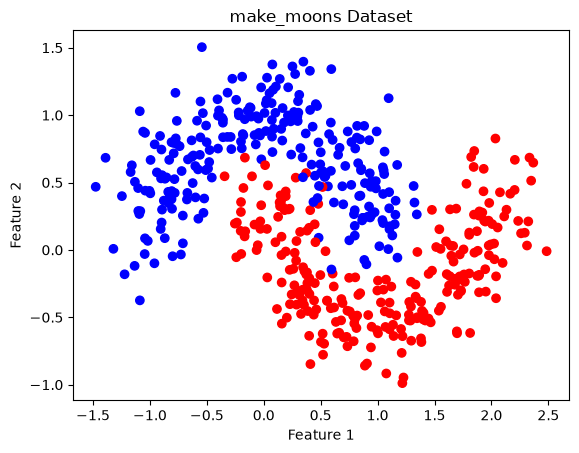

In [6]:
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title("make_moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [8]:
X = StandardScaler().fit_transform(X) # normalize

In [9]:
X = torch.tensor(X, dtype=torch.float32)

In [10]:
y = torch.tensor(y.reshape(-1,1), dtype=torch.float32)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
class BigMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 16)
        self.fc6 = nn.Linear(16, 8)
        self.fc7 = nn.Linear(8, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = F.relu(self.fc6(x))
        return torch.sigmoid(self.fc7(x))

In [13]:
model_fp32 = BigMLP()

In [14]:
model_fp32.parameters()

<generator object Module.parameters at 0xf8220e504e40>

In [17]:
optimizer = torch.optim.Adam(model_fp32.parameters(), lr=0.01)

In [19]:
loss_fn = nn.BCELoss()

In [20]:
for epoch in range(2000):
    model_fp32.train()
    optimizer.zero_grad()
    out = model_fp32(X_train)
    loss = loss_fn(out, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item():.4f}")

Epoch: 0 | Loss: 0.6945
Epoch: 500 | Loss: 0.0091
Epoch: 1000 | Loss: 0.0137
Epoch: 1500 | Loss: 0.5765


In [23]:
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X)
        preds = (preds > 0.5).float()
        return (preds == y).float().mean().item()

In [24]:
print("\nFP32 Accuracy:", accuracy(model_fp32, X, y))


FP32 Accuracy: 0.9860000014305115


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_fp_32 = model_fp32.to(device)
X = X.to(device)   # your input tensors too — both must be on the same device

In [34]:
torch.backends.quantized.engine = 'qnnpack'
model_fp32 = model_fp32.to("cuda")     # quantization stays on CPU
model_int8 = quantize_dynamic(model_fp32, {nn.Linear}, dtype=torch.qint8)

/tmp/ipykernel_2462708/2195363223.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = quantize_dynamic(model_fp32, {nn.Linear}, dtype=torch.qint8)


RuntimeError: It looks like you are trying to quantize a CUDA tensor while QNNPACK backend is enabled. Although not expected to happen in practice, you might have done it for testing purposes. Please, either change the quantization engine or move the tensor to a CPU.

In [32]:
# Dynamic int8 quantization
model_int8 = quantize_dynamic(
    model_fp32,
    {nn.Linear},
    dtype=torch.qint8
)

/tmp/ipykernel_2462708/2954352237.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = quantize_dynamic(


In [33]:
print("INT8 Quantized: ", accuracy(model_int8, X, y))

NotImplementedError: Could not run 'quantized::linear_dynamic' with arguments from the 'CUDA' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'quantized::linear_dynamic' is only available for these backends: [CPU, Meta, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradXLA, AutogradMPS, AutogradXPU, AutogradHPU, AutogradLazy, AutogradMTIA, AutogradMAIA, AutogradPrivateUse1, AutogradMeta, Tracer, AutocastCPU, AutocastMTIA, AutocastMAIA, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, FuncTorchVmapMode, Batched, VmapMode, FuncTorchGradWrapper, PythonTLSSnapshot, FuncTorchDynamicLayerFrontMode, PreDispatch, Python